In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")

print("Path to dataset files:", path)

Path to dataset files: /home/hermann/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8


In [3]:
data = pd.read_csv(f"{path}/marketing_campaign.csv", sep=";")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
data.shape

(2240, 29)

In [5]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Analyse des variables de campagnes

In [7]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

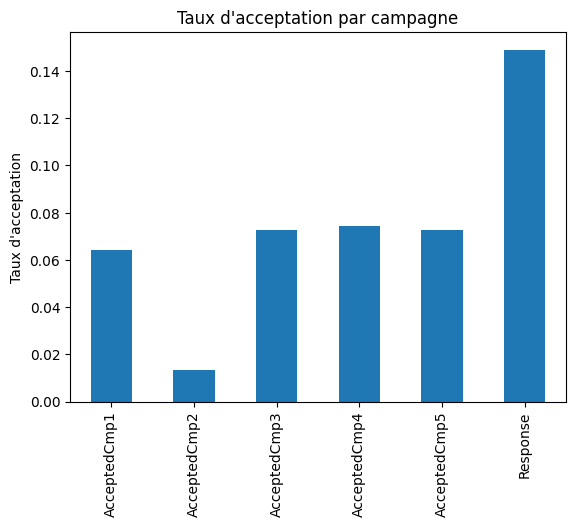

In [10]:
data[campaign_cols].mean().plot(kind='bar')
plt.title('Taux d\'acceptation par campagne')
plt.ylabel('Taux d\'acceptation')
plt.show()

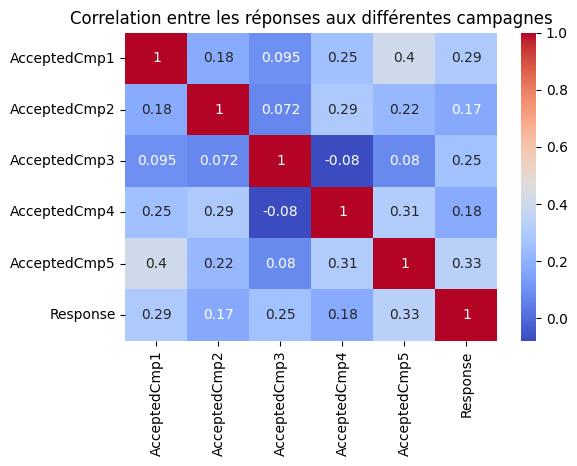

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(data[campaign_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation entre les réponses aux différentes campagnes')
plt.show()

### Segmentation par Dépenses

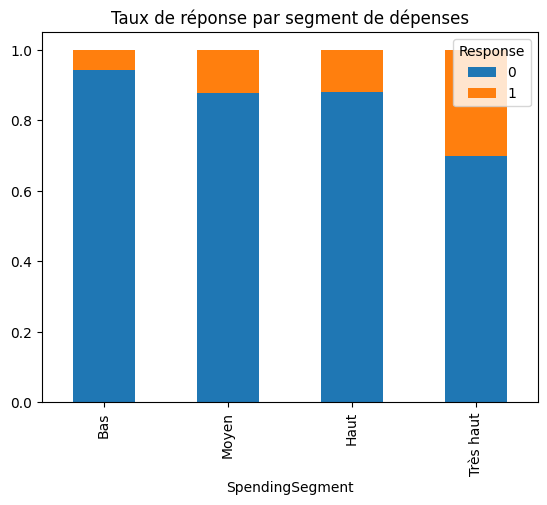

In [13]:
data['TotalSpent'] = data[['MntFishProducts', 'MntMeatProducts', 'MntFruits', 
                      'MntSweetProducts', 'MntWines', 'MntGoldProds']].sum(axis=1)

data['SpendingSegment'] = pd.qcut(data['TotalSpent'], q=4, labels=['Bas', 'Moyen', 'Haut', 'Très haut'])
pd.crosstab(data['SpendingSegment'], data['Response'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Taux de réponse par segment de dépenses')
plt.show()

### Analyse Démographique

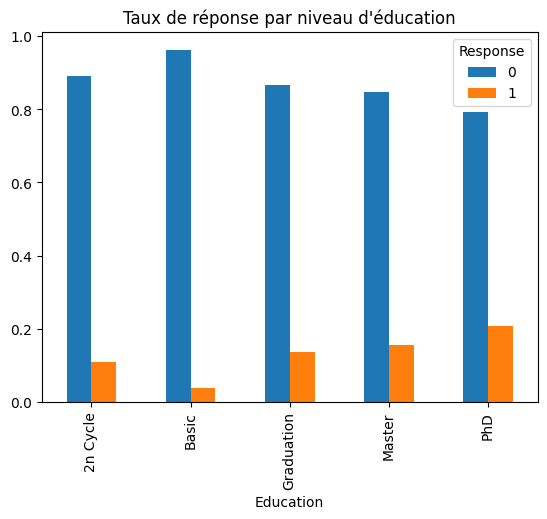

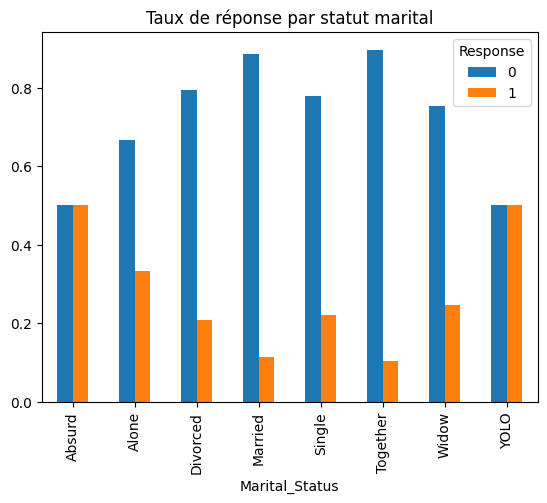

In [15]:
pd.crosstab(data['Education'], data['Response'], normalize='index').plot(kind='bar')
plt.title('Taux de réponse par niveau d\'éducation')
plt.show()

# Taux de réponse par statut marital
pd.crosstab(data['Marital_Status'], data['Response'], normalize='index').plot(kind='bar')
plt.title('Taux de réponse par statut marital')
plt.show()

### Analyse comportementale

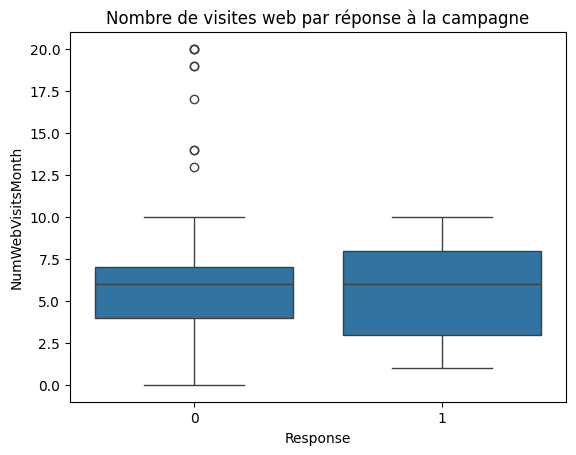

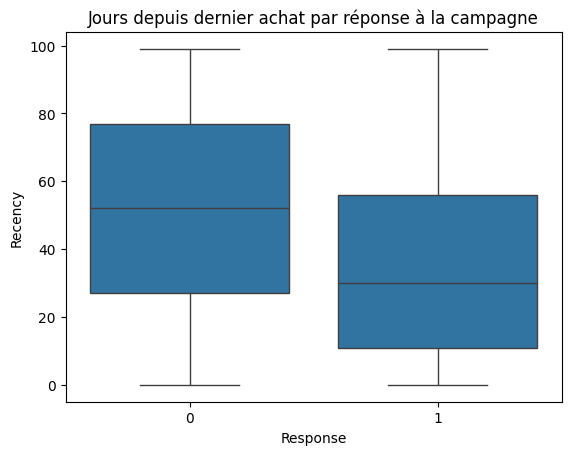

In [16]:
# Relation entre nombre de visites web et réponse aux campagnes
sns.boxplot(x='Response', y='NumWebVisitsMonth', data=data)
plt.title('Nombre de visites web par réponse à la campagne')
plt.show()

# Relation entre jours depuis dernier achat et réponse
sns.boxplot(x='Response', y='Recency', data=data)
plt.title('Jours depuis dernier achat par réponse à la campagne')
plt.show()

In [17]:
# Calculer la valeur client moyenne par segment
rentability = data.groupby('SpendingSegment').agg({
    'TotalSpent': 'mean',
    'Response': 'mean',
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean'
}).sort_values('TotalSpent', ascending=False)

print(rentability)

                  TotalSpent  Response  NumWebPurchases  NumStorePurchases
SpendingSegment                                                           
Très haut        1490.475000  0.300000         5.605357           8.478571
Haut              709.819320  0.118068         6.100179           7.958855
Moyen             184.573975  0.122995         3.262032           3.996435
Bas                39.262500  0.055357         1.376786           2.733929


/tmp/ipykernel_34700/2477052799.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rentability = data.groupby('SpendingSegment').agg({


### Analyse temporelle

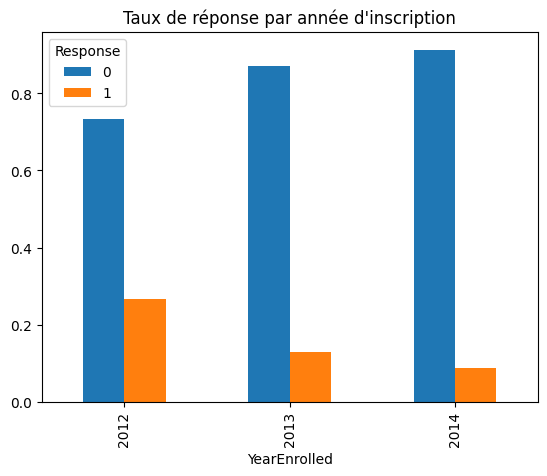

In [23]:
# Extraire l'année d'inscription
data['YearEnrolled'] = pd.to_datetime(data['Dt_Customer']).dt.year

# Taux de réponse par année d'inscription
pd.crosstab(data['YearEnrolled'], data['Response'], normalize='index').plot(kind='bar')
plt.title('Taux de réponse par année d\'inscription')
plt.show()

In [24]:
# Créer un segment combinant plusieurs caractéristiques
conditions = [
    (data['TotalSpent'] > data['TotalSpent'].quantile(0.75)) & (data['NumWebVisitsMonth'] > 5),
    (data['TotalSpent'] > data['TotalSpent'].quantile(0.75)) & (data['NumStorePurchases'] > 5),
    (data['Income'] > data['Income'].quantile(0.75))
]

choices = ['Hautes dépenses - Actifs en ligne', 'Hautes dépenses - Actifs en magasin', 'Hauts revenus']
data['CustomSegment'] = np.select(conditions, choices, default='Autres')

# Analyser la réponse par segment personnalisé
pd.crosstab(data['CustomSegment'], data['Response'], normalize='index').sort_values(1, ascending=False)

Response,0,1
CustomSegment,,
Hautes dépenses - Actifs en ligne,0.692857,0.307143
Hautes dépenses - Actifs en magasin,0.723837,0.276163
Hauts revenus,0.792271,0.207729
Autres,0.901227,0.098773


In [26]:
# Exemple de calcul RFM
data['RFM_Score'] = pd.qcut(data['Recency'], q=5, labels=False) + \
                 pd.qcut(data['NumStorePurchases'] + data['NumWebPurchases'], q=5, labels=False) + \
                 pd.qcut(data['TotalSpent'], q=5, labels=False)

Taux de réponse moyen (global): 14.91%
Taux de réponse top 20%: 33.71%


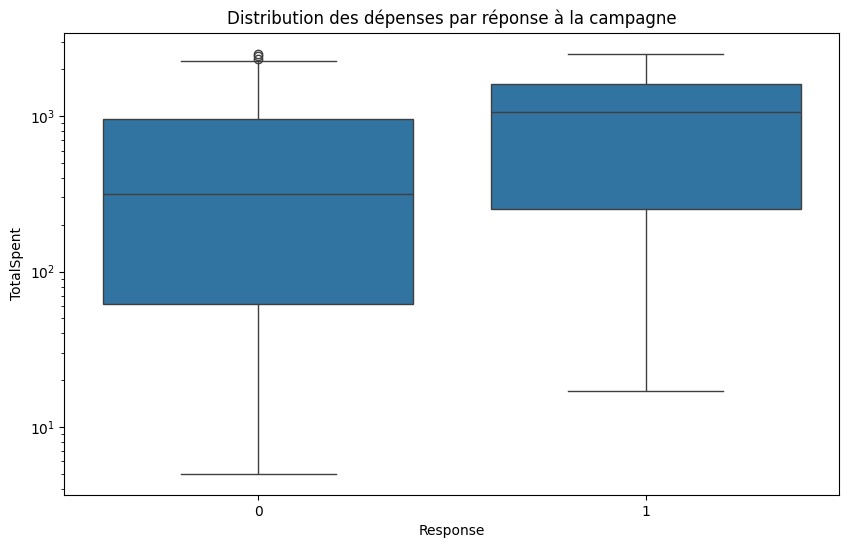

In [30]:
top_20 = data.nlargest(int(len(data)*0.2), 'TotalSpent')

# Analyse comparative
print(f"Taux de réponse moyen (global): {data['Response'].mean():.2%}")
print(f"Taux de réponse top 20%: {top_20['Response'].mean():.2%}")

# Visualisation
plt.figure(figsize=(10,6))
sns.boxplot(x='Response', y='TotalSpent', data=data)
plt.title('Distribution des dépenses par réponse à la campagne')
plt.yscale('log')  # Pour mieux visualiser les écarts
plt.show()

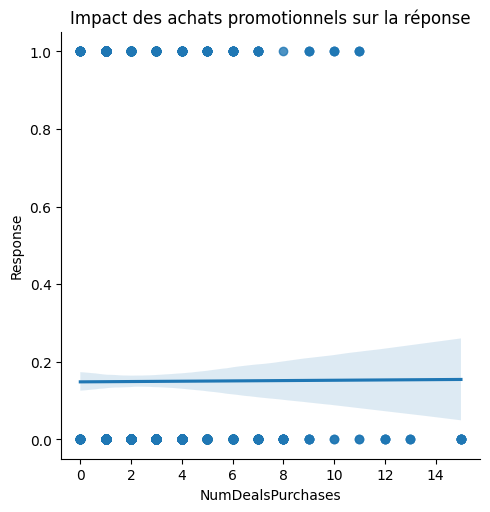

In [46]:
# Création de segments
data['MainChannel'] = np.where(
    data['NumWebPurchases'] > data['NumStorePurchases'], 
    'Online', 
    'Store'
)

# Analyse comparative
channel_analysis = data.groupby('MainChannel').agg({
    'Response': 'mean',
    'TotalSpent': 'mean',
    'NumDealsPurchases': 'mean'
}).sort_values('Response', ascending=False)

# Impact des promotions
sns.lmplot(x='NumDealsPurchases', y='Response', data=data)
plt.title('Impact des achats promotionnels sur la réponse')
plt.show()

In [35]:
import re

# Calcul des scores RFM
data['RecencyScore'] = pd.qcut(data['Recency'], q=5, labels=[5,4,3,2,1])
data['FrequencyScore'] = pd.qcut(data['NumWebPurchases']+data['NumStorePurchases'], q=5, labels=[1,2,3,4,5])
data['MonetaryScore'] = pd.qcut(data['TotalSpent'], q=5, labels=[1,2,3,4,5])

# Création des segments
segments = {
    r'[4-5][4-5][4-5]': 'Champions',
    r'[3-5][1-5][3-5]': 'Clients fidèles',
    r'[4-5]11': 'Nouveaux clients',
    r'[1-2][4-5][4-5]': 'Clients à risque',
    r'[1-2]1[1-2]': 'Dormeurs'
}

data['RFM_Segment'] = data.apply(lambda x: next((v for k,v in segments.items() 
                                           if re.match(k, f"{x.RecencyScore}{x.FrequencyScore}{x.MonetaryScore}")), 
                                           'Autres'), axis=1)

# Analyse des segments
rfm_analysis = data.groupby('RFM_Segment').agg({
    'Response': 'mean',
    'TotalSpent': 'mean',
    'ID': 'count'
}).sort_values('Response', ascending=False)

In [36]:
rfm_analysis

,Response,TotalSpent,ID
RFM_Segment,,,
Champions,0.295455,1214.878788,264
Clients fidèles,0.204082,825.899814,539
Clients à risque,0.142857,1234.909774,266
Autres,0.121172,324.656458,751
Nouveaux clients,0.064706,31.252941,170
Dormeurs,0.024000,53.936000,250


In [38]:
# Comparaison des taux
complaint_analysis = pd.pivot_table(data, values='Response', 
                                   index='Complain', 
                                   aggfunc=['mean','count'])

# Test statistique
from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(pd.crosstab(data['Complain'], data['Response']))
print(f"Test d'indépendance (p-value): {p:.4f}")

Test d'indépendance (p-value): 1.0000


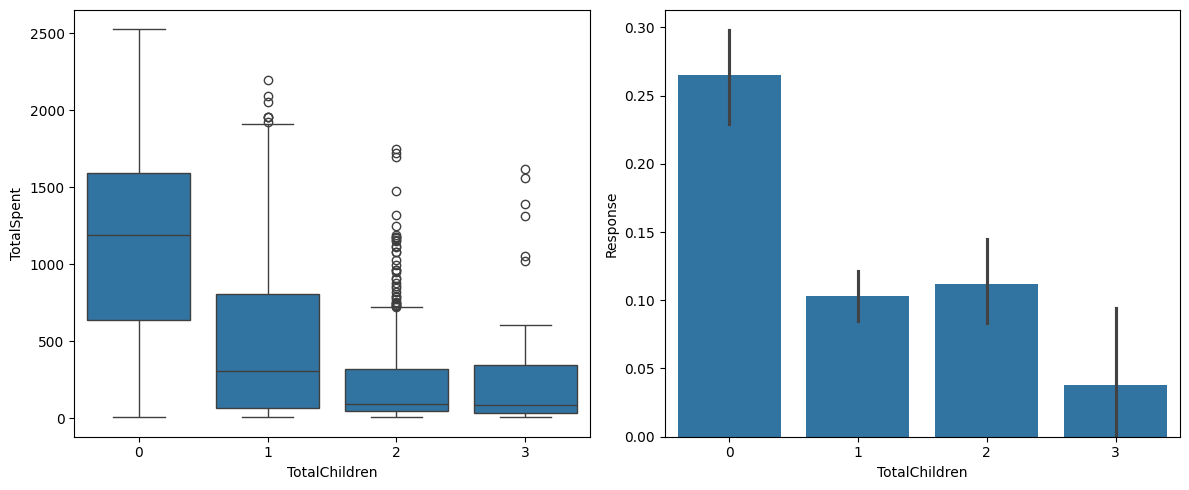

In [43]:
# Création d'une variable composite
data['TotalChildren'] = data['Kidhome'] + data['Teenhome']
data['FamilySize'] = np.where(data['Marital_Status'].str.contains('Married'), data['TotalChildren']+2, data['TotalChildren']+1)

# Analyse visuelle
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='TotalChildren', y='TotalSpent', data=data)
plt.subplot(1,2,2)
sns.barplot(x='TotalChildren', y='Response', data=data)
plt.tight_layout()
plt.show()